## Simple Illustration for RTD (original scale)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_runtime_distribution(num_samples: int, lb: float, ub: float, show_y: bool = False):
    """
    Samples from a heavy-tailed lognormal distribution peaking at lb, 
    bounded by ub, and plots the density and individual points.
    """
    if lb <= 0:
        raise ValueError("Lower bound (lb) must be > 0 to act as the lognormal peak (mode).")
    if ub <= lb:
        raise ValueError("Upper bound (ub) must be strictly greater than lower bound (lb).")

    # Define shape (sigma) for a heavy tail, and calculate mu so the mode equals `lb`
    sigma = 1.0  
    mu = np.log(lb) + sigma**2
    
    # Rejection sampling to enforce the upper bound
    samples = []
    while len(samples) < num_samples:
        np.random.seed(42)  # For reproducibility
        batch = np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)
        valid = batch[batch <= ub]
        samples.extend(valid)
        
    samples = np.array(samples[:num_samples])
    
    # ---------------- Plotting ----------------
    fig, ax = plt.subplots(figsize=(10, 3))
    
    # Calculate Kernel Density Estimate (KDE) for the smooth curve
    x_eval = np.linspace(0, ub, 1000)
    kde = gaussian_kde(samples)
    y_eval = kde(x_eval)
    
    # Plot the filled density curve
    ax.fill_between(x_eval, y_eval, alpha=0.4, color='#a0b9d9', linewidth=0)
    
    # Plot individual samples on the x-axis as crosses
    ax.plot(samples, np.zeros_like(samples), 'x', color='#004488', markersize=8, markeredgewidth=1.5)
    
    # Axis formatting
    ax.set_xlabel("runtime (s)", fontsize=12, labelpad=8, color="#333333")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    
    if show_y:
        ax.set_ylabel("Density", fontsize=12)
        ax.spines['left'].set_visible(True)
    else:
        ax.spines['left'].set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    return fig


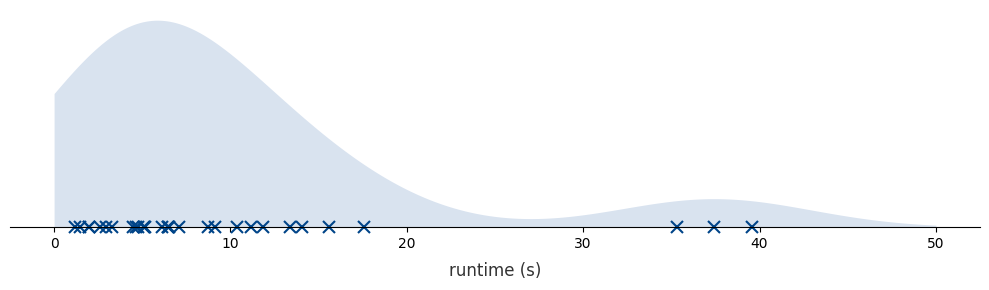

In [45]:
fig = plot_runtime_distribution(num_samples=30, lb=3, ub=50, show_y=False)
fig.savefig("rtd_example.pdf", format='pdf', bbox_inches='tight')


## TabPFN's predicted RTDs

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_runtime_distributions_pfn(model, X_test, y_test, n_instances, n_pfn_bins=None, show_y_axis=True, layout_grid=None, plot_title=None, test_instance_number=None):
    """
    Samples test instances, predicts their runtime distribution using TabPFN, 
    and plots the predicted density against the actual runtime observations.
    """
    N_test = X_test.shape[0]
    
    # 1. Determine instances to plot
    if test_instance_number is not None:
        if test_instance_number < 0 or test_instance_number >= N_test:
            raise ValueError(f"test_instance_number ({test_instance_number}) out of bounds (0 to {N_test-1}).")
        sampled_idx = np.array([test_instance_number])
        n_instances = 1  # Override to cleanly plot just this single instance
    else:
        if n_instances > N_test:
            raise ValueError(f"n_instances ({n_instances}) cannot exceed test set size ({N_test}).")
        sampled_idx = np.random.choice(N_test, size=n_instances, replace=False)
    
    X_batch = X_test[sampled_idx]
    
    # Assumes y_test is already log-scaled
    y_batch = y_test[sampled_idx]  
    
    # 2. Predict using the fitted tabpfn model
    preds = model.predict(X_batch, output_type="full")
    logits = preds['logits']
    criterion = preds['criterion']
    
    # Ensure logits is a torch tensor for softmax computation
    if not isinstance(logits, torch.Tensor):
        logits = torch.tensor(logits)
    else:
        logits = logits.detach().cpu()
        
    # Extract distribution borders and widths to calculate density
    borders = criterion.borders.detach().cpu().numpy()
    bucket_widths = criterion.bucket_widths.detach().cpu().numpy()
    
    # 3. Generate plots for each predicted test instance
    if layout_grid is not None:
        n_rows, n_cols = layout_grid
        if n_rows * n_cols < n_instances:
            raise ValueError(f"layout_grid {layout_grid} is too small for {n_instances} instances.")
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    else:
        fig, axes = plt.subplots(n_instances, 1, figsize=(10, 4 * n_instances), squeeze=False)
    
    axes = axes.flatten()
    
    # Hide any extra empty subplots if grid capacity exceeds n_instances
    for j in range(n_instances, len(axes)):
        axes[j].set_visible(False)
    
    for i in range(n_instances):
        ax = axes[i]
        
        # Calculate base probabilities
        probs = torch.softmax(logits[i], dim=-1).numpy()
        
        # --- Apply custom binning if n_pfn_bins is provided ---
        if n_pfn_bins is not None:
            # Interpolate the piecewise linear CDF to get accurate new bin probabilities
            orig_cdf = np.concatenate([[0.0], np.cumsum(probs)])
            plot_borders = np.linspace(borders[0], borders[-1], n_pfn_bins + 1)
            new_cdf = np.interp(plot_borders, borders, orig_cdf)
            
            plot_probs = np.diff(new_cdf)
            plot_widths = np.diff(plot_borders)
        else:
            plot_borders = borders
            plot_probs = probs
            plot_widths = bucket_widths
            
        # Prevent RuntimeWarning by forcing a tiny minimum width
        safe_widths = np.maximum(plot_widths, 1e-10)
        plot_density = plot_probs / safe_widths
        
        # Plot predicted distribution as a single continuous stepped polygon
        # We append a dummy value to match the length of plot_borders for 'post' stepping
        extended_density = np.append(plot_density, plot_density[-1])
        ax.fill_between(plot_borders, 0, extended_density, step='post', 
                        color='#cccccc', alpha=1.0, edgecolor='none')
        
        # Overlay actual observations on the x-axis (y=0)
        y_obs = y_batch[i]
        ax.plot(y_obs, np.zeros_like(y_obs), 'x', color='#004488', 
                markersize=8, markeredgewidth=1.5, alpha=0.9, zorder=3, clip_on=False)
        
        # --- Trim X-Axis bounds using 1% and 99% ICDF ---
        cumprobs = np.cumsum(probs)
        idx_lower = np.searchsorted(cumprobs, 0.001)
        idx_upper = np.searchsorted(cumprobs, 0.999)
        
        # Guard against out-of-bounds indices
        idx_lower = min(max(idx_lower, 0), len(borders) - 2)
        idx_upper = min(max(idx_upper, 0), len(borders) - 2)
        
        pred_min = borders[idx_lower]
        pred_max = borders[idx_upper + 1]
        
        # Adjust the x-axis span based on 1st/99th percentile vs empirical data
        x_min = min(pred_min, y_obs.min())
        x_max = max(pred_max, y_obs.max())
        
        # Add a slight 2% margin to the bounds
        margin = max((x_max - x_min) * 0.02, 1e-5)
        ax.set_xlim(x_min - margin, x_max + margin)
        
        # --- Styling adjustments to match attachment ---
        ax.set_ylim(bottom=0) # Make bars rest flush on the x-axis
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        
        ax.set_xlabel("log runtime (s)", fontsize=12, color='#333333')
        ax.set_ylabel("Density", fontsize=12, color='#333333')
        # ax.set_title(f"Instance {sampled_idx[i]}", fontsize=10, color='#333333')
        ax.tick_params(colors='#333333')
        if not show_y_axis:
            ax.get_yaxis().set_visible(False)
            ax.spines['left'].set_visible(False)
        
    if plot_title:
        fig.suptitle(plot_title, fontsize=16, fontweight='bold')
        # Leave 4% of the figure height at the top for the title
        plt.tight_layout(rect=[0, 0, 1, 0.96])
    else:
        plt.tight_layout()
        
    return fig

In [38]:
import torch
from tabpfn_project.helper.load_data import load_distnet_data
from tabpfn_project.globals import SCENARIOS
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
from tabpfn_project.helper.utils import subsample_data
from tabpfn_project.helper.preprocess import preprocess_feats

print(SCENARIOS)
context_size = 4096
fold = 0

def run_pfn_on_instance(scenario, test_instance_number):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TabPFNRegressor.create_default_for_version(ModelVersion.V2_5, ignore_pretraining_limits=True, device=device, random_state=0)
    X_train, X_test, y_train, y_test = load_distnet_data(scenario, fold)
    train_group_ids = np.arange(X_train.shape[0])

    X_train_flat = np.repeat(X_train, repeats=100, axis=0)
    y_train_flat = y_train.reshape(-1, 1)
    train_group_ids_flat = np.repeat(train_group_ids, repeats=100)

    X_train_flat, y_train_flat, train_group_ids_flat = subsample_data(
                X_train_flat, y_train_flat, train_group_ids_flat, context_size=context_size, 
                seed=100, with_replacement=True
            )

    X_train_flat, X_test = preprocess_feats(X_train_flat, X_test)
    y_train_scaled = np.log1p(y_train_flat)
    y_test_scaled = np.log1p(y_test)


    model.fit(X_train_flat, y_train_scaled.ravel())
    fig = plot_runtime_distributions_pfn(model, X_test, y_test_scaled, n_instances=1, show_y_axis=True, test_instance_number=test_instance_number)
    fig.savefig(f"tabpfn_predicted_rtd_{scenario}_{test_instance_number}.pdf", format="pdf", bbox_inches='tight')

# for scenario in SCENARIOS:
#     run_pfn_on_instance(model, context_size, fold, scenario)


['clasp_factoring', 'saps-CVVAR', 'spear_qcp', 'yalsat_qcp', 'spear_swgcp', 'yalsat_swgcp', 'lpg-zeno']


Train data loaded
Could not find test data
(20000, 54) (20000, 100)
Discarding 0 (20000) instances because of CRASHED
Discarding 9989 (20000) instances because of TIMEOUT
Discarding 0 (10011) instances because not stated TIMEOUTS
Discarding 0 (10011) instances because of constant features
Discarding 0 (10011) instances because of UNSAT
Imputed 0 values with median


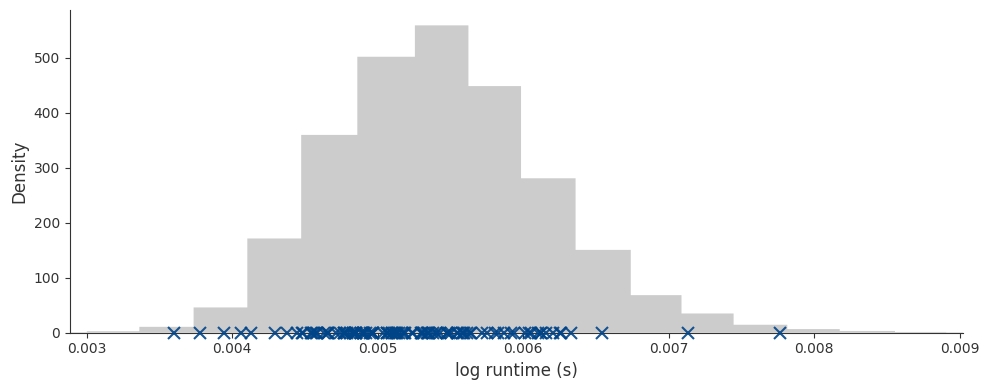

In [39]:
run_pfn_on_instance("saps-CVVAR", test_instance_number=882)